## Run a pipeline adding a custom algorithm

This process will run the entire pipeline described in a configuration file and will add a custom algorithm to it

## Import dependencies

In [1]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

## Instantiate the Pipeline class

When you instantiate the pipeline class, it will install some dependencies described in the configuration file that are necessary for the custom algorithm

In [2]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")

This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py"
      class_name: "MyMethod"
      dependencies: "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm

In [3]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                },
                "mode": "percent"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "min_max_data",
            "file_path": "example",
            "class_name": "MyMethod",
            "step_name": "custom",
            "test": false,
            "processing_type": "image",
            "dependencies": "scikit-learn",
            "params": {
                "raise_error": false,
                "feature_range": "(0, 1)"
            }
        }
    ]
}

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'output_path': PosixPath('output'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_open_args': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'n_jobs': 1,
   'track_changes': True,
   'rename': 'datetime',
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'test': False,
     'params': {'value': 0.1, 'raise_error': False},
     'mode': 'percent'}]}),
 ('colour_correction',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'name': 'colour_correction',
   'step_name': 'colour',
   'test': False,
   'params': {'method': 'opencv',
    'invert_colours': False,
    'raise

The `min_max_data` is a custom algorithm available in `file_path`: `/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py`

In [6]:
# Run the pipeline
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Running step 0: raw - OpenLayer
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Number of images to be removed: 44. Total number of images: 49


Open Images: 100%|███████████████████████████████████| 5/5 [00:00<00:00, 706.94it/s]

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Running step 1: colour_correction - ColourLayer



Processing images: 100%|███████████████████████████| 5/5 [00:00<00:00, 16320.25it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Step 1 completed
☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Running step 2: min_max_data - CustomLayer


Processing images: 100%|████████████████████████████| 5/5 [00:00<00:00, 2272.35it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-03 15:18:56 | Step 2 completed


Step: raw
Image: [[[111 142 135 255]
  [108 141 134 255]
  [106 140 134 255]
  ...
  [143 168 155 255]
  [148 171 160 255]
  [146 169 158 255]]

 [[109 143 135 255]
  [110 141 134 255]
  [110 141 136 255]
  ...
  [144 168 157 255]
  [148 169 157 255]
  [147 169 157 255]]

 [[110 141 136 255]
  [111 141 136 255]
  [107 139 134 255]
  ...
  [145 167 158 255]
  [146 169 158 255]
  [145 169 158 255]]

 ...

 [[130 148 139 255]
  [130 147 141 255]
  [159 159 146 255]
  ...
  [129 152 145 255]
  [128 153 144 255]
  [130 155 147 255]]

 [[128 144 136 255]
  [138 149 141 255]
  [168 162 147 255]
  ...
  [128 151 143 255]
  [128 152 144 255]
  [137 157 150 255]]

 [[130 145 138 255]
  [157 155 143 255]
  [163 161 147 255]
  ...
  [133 153 144 255]
  [129 152 144 255]
  [134 157 150 255]]]
Image: [[[102 135 131 255]
  [102 135 130 255]
  [104 137 133 255]
  ...
  [ 89 129 120 255]
  [ 91 128 121 255]
  [ 87 128 122 255]]

 [[103 137 134 255]
  [107 140 136 255]
  [102 136 132 255]
  ...
  [ 89 130 122 255]
  [ 91 131 124 255]
  [ 92 129 123 255]]

 [[107 138 135 255]
  [106 141 137 255]
  [108 139 135 255]
  ...
  [ 92 131 125 255]
  [ 88 128 120 255]
  [ 88 127 122 255]]

 ...

 [[101 126 122 255]
  [106 126 122 255]
  [157 149 138 255]
  ...
  [ 83 120 115 255]
  [ 80 115 111 255]
  [ 83 119 116 255]]

 [[102 125 120 255]
  [117 128 121 255]
  [168 156 145 255]
  ...
  [ 85 120 116 255]
  [ 77 115 112 255]
  [ 77 115 112 255]]

 [[106 125 121 255]
  [158 149 138 255]
  [159 152 137 255]
  ...
  [ 88 122 119 255]
  [ 84 120 117 255]
  [ 81 117 114 255]]]
Image: [[[128 156 151 255]
  [133 159 154 255]
  [132 158 153 255]
  ...
  [159 181 166 255]
  [160 181 167 255]
  [162 182 169 255]]

 [[128 155 151 255]
  [131 158 152 255]
  [135 160 156 255]
  ...
  [163 183 169 255]
  [164 182 168 255]
  [161 182 170 255]]

 [[131 155 150 255]
  [131 157 153 255]
  [133 159 154 255]
  ...
  [160 181 167 255]
  [164 182 169 255]
  [162 183 171 255]]

 ...

 [[117 137 134 255]
  [129 143 140 255]
  [151 149 142 255]
  ...
  [145 165 159 255]
  [146 165 159 255]
  [139 163 159 255]]

 [[116 136 134 255]
  [132 141 136 255]
  [157 157 144 255]
  ...
  [146 168 162 255]
  [148 167 163 255]
  [145 164 159 255]]

 [[119 136 135 255]
  [156 154 146 255]
  [158 155 143 255]
  ...
  [146 165 159 255]
  [144 163 157 255]
  [147 165 160 255]]]
Image: [[[ 22  68  61 255]
  [ 22  66  62 255]
  [ 23  69  63 255]
  ...
  [ 34  79  68 255]
  [ 34  78  71 255]
  [ 36  81  73 255]]

 [[ 23  69  65 255]
  [ 24  69  64 255]
  [ 18  66  60 255]
  ...
  [ 39  85  77 255]
  [ 37  80  72 255]
  [ 35  78  71 255]]

 [[ 23  70  64 255]
  [ 24  68  64 255]
  [ 24  72  66 255]
  ...
  [ 42  85  77 255]
  [ 33  78  73 255]
  [ 33  77  70 255]]

 ...

 [[ 12  47  44 255]
  [  7  44  44 255]
  [126 105  98 255]
  ...
  [ 18  59  57 255]
  [ 24  68  66 255]
  [ 22  58  56 255]]

 [[ 17  46  46 255]
  [ 36  51  50 255]
  [153 136 127 255]
  ...
  [ 21  60  57 255]
  [ 18  54  53 255]
  [ 24  63  61 255]]

 [[  8  38  38 255]
  [152 129 120 255]
  [161 138 125 255]
  ...
  [ 22  57  56 255]
  [ 18  56  53 255]
  [ 18  55  54 255]]]
Image: [[[ 25  71  64 255]
  [ 25  70  65 255]
  [ 22  69  62 255]
  ...
  [ 43  85  75 255]
  [ 35  79  69 255]
  [ 34  79  71 255]]

 [[ 21  67  62 255]
  [ 24  71  64 255]
  [ 25  72  66 255]
  ...
  [ 44  89  79 255]
  [ 38  86  77 255]
  [ 37  82  74 255]]

 [[ 27  70  62 255]
  [ 27  73  70 255]
  [ 27  75  68 255]
  ...
  [ 46  88  80 255]
  [ 37  82  73 255]
  [ 41  84  75 255]]

 ...

 [[ 13  49  45 255]
  [  8  49  49 255]
  [122 104  95 255]
  ...
  [ 19  60  56 255]
  [ 20  59  54 255]
  [ 23  63  58 255]]

 [[ 17  49  47 255]
  [ 36  53  51 255]
  [154 136 125 255]
  ...
  [ 26  60  55 255]
  [ 22  60  58 255]
  [ 18  55  53 255]]

 [[  7  38  37 255]
  [154 129 119 255]
  [165 139 129 255]
  ...
  [ 19  57  52 255]
  [ 21  55  54 255]
  [ 21  58  57 255]]]
Step: colour_correction
Image: [[[132]
  [130]
  [129]
  ...
  [159]
  [163]
  [161]]
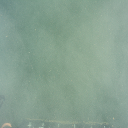
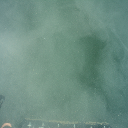
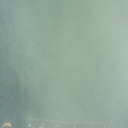
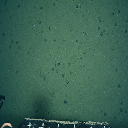
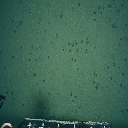
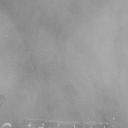
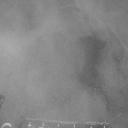
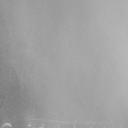
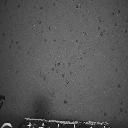
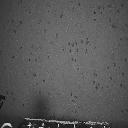
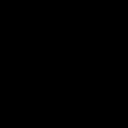
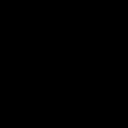
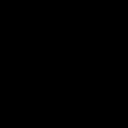
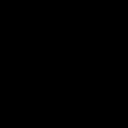
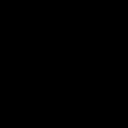

In [8]:
# See the images output
pipeline.images